# Experiment 2 — learning curves

Metric vs **training-set size** (nested subsets). One line per method, averaged over the folds of every included dataset (linear x). Each metric is shown three ways: raw points, **moving average** (the trend), and **relative** to each method's own best. Figures → `figures/experiment2/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2


In [2]:
pd_df  = load_summary(SUMMARY_DIR, experiment='experiment2', task='pd', aggregated=False)
try:
    lgd_df = load_summary(SUMMARY_DIR, experiment='experiment2', task='lgd', aggregated=False)
except FileNotFoundError:
    lgd_df = None
print(f'PD: {pd_df["method"].nunique()} methods, {pd_df["dataset"].nunique()} datasets, '
      f'{pd_df["sweep_value"].nunique()} sweep points')

PD: 3 methods, 9 datasets, 1161 sweep points


## PD — AUC (points, moving average, relative)

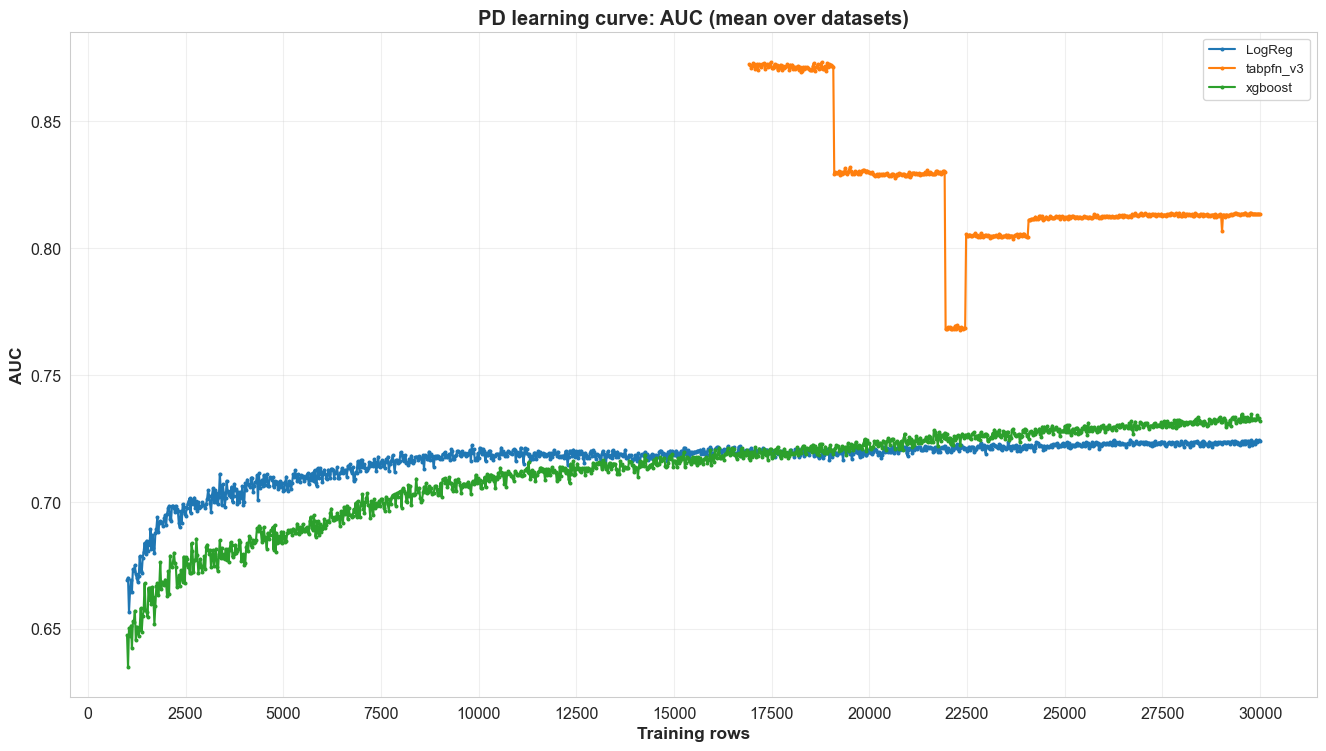

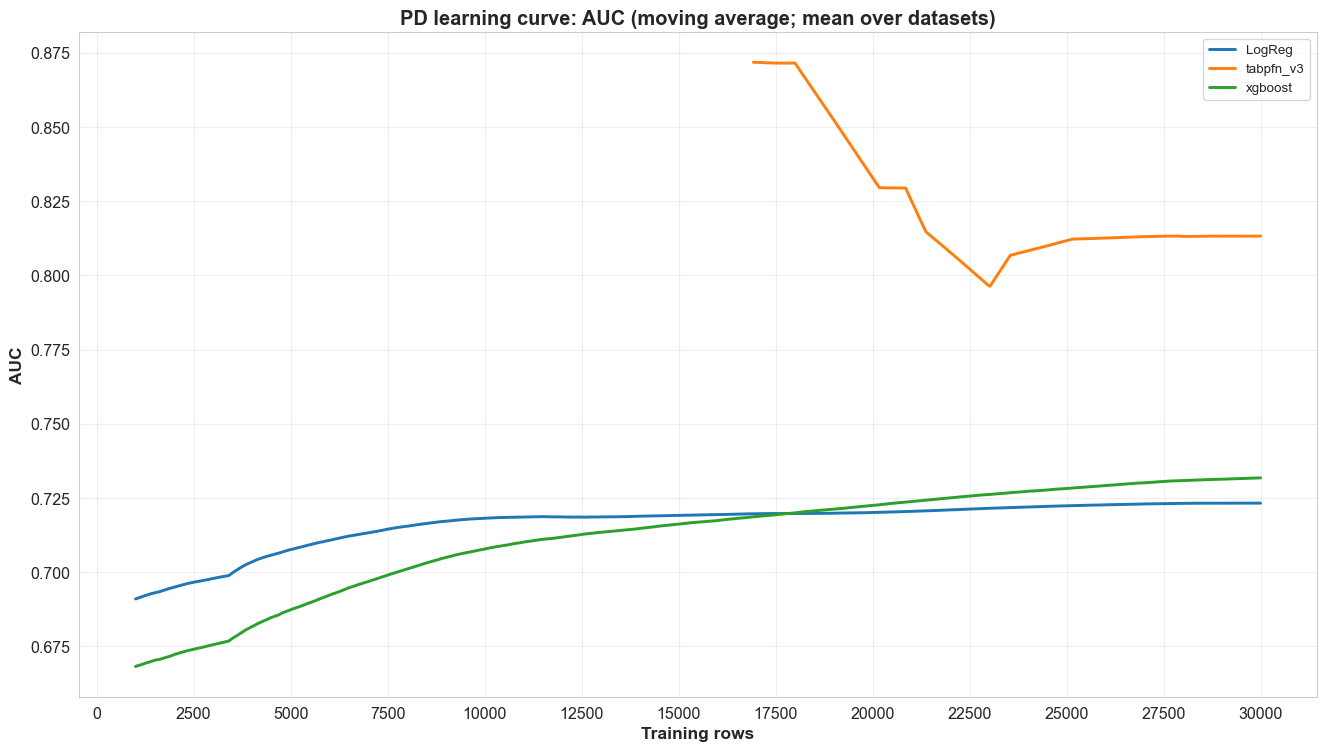

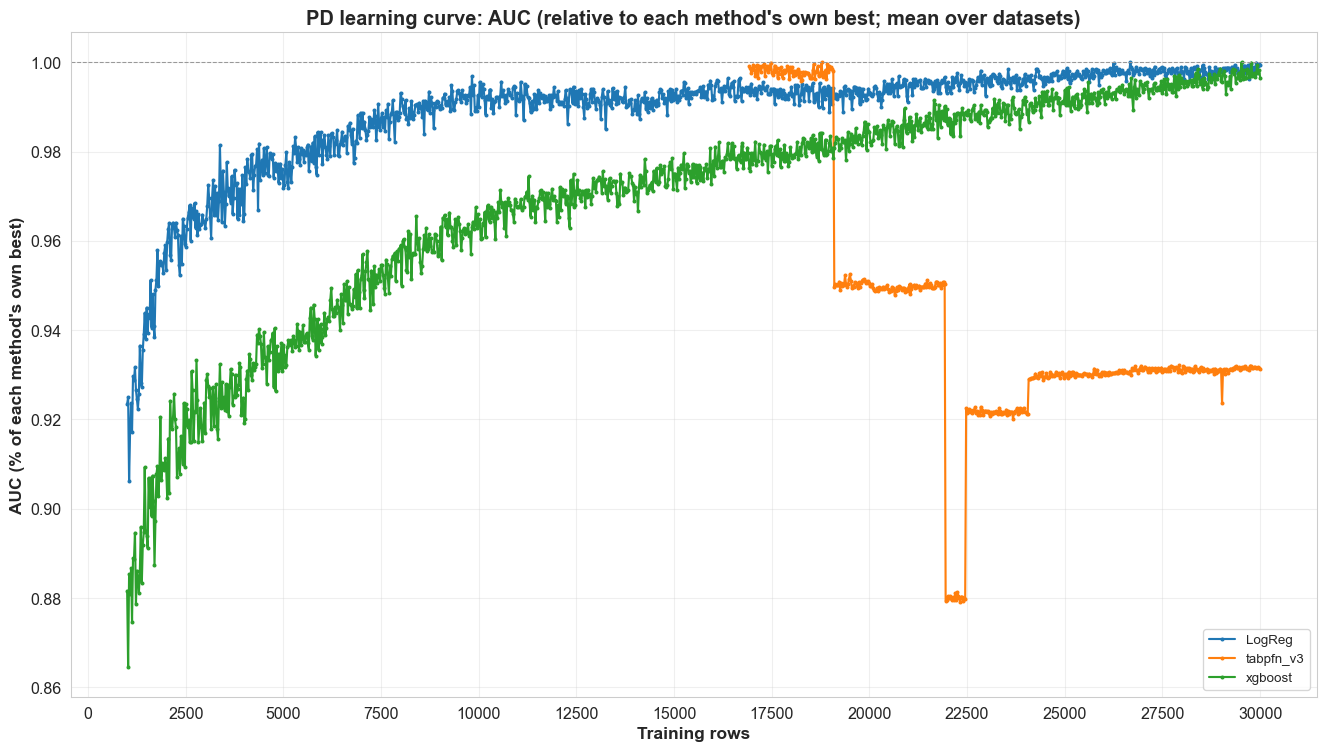

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc_relative.pdf')

In [3]:
learning_curve(pd_df, 'AUC', task_name='PD', out_dir=FIGURES_DIR / 'pd')
learning_curve(pd_df, 'AUC', task_name='PD', smooth=True,   out_dir=FIGURES_DIR / 'pd')
learning_curve(pd_df, 'AUC', task_name='PD', relative=True, out_dir=FIGURES_DIR / 'pd')

## PD — Brier (lower is better)

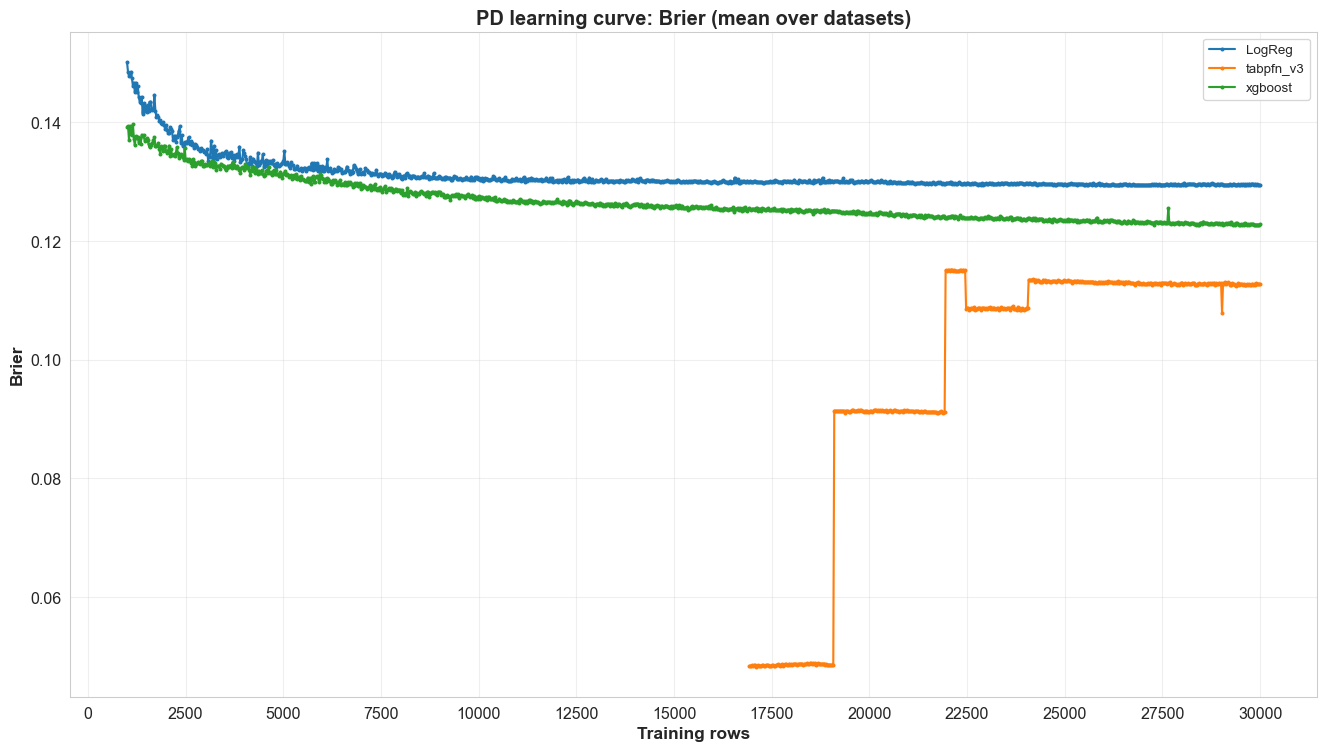

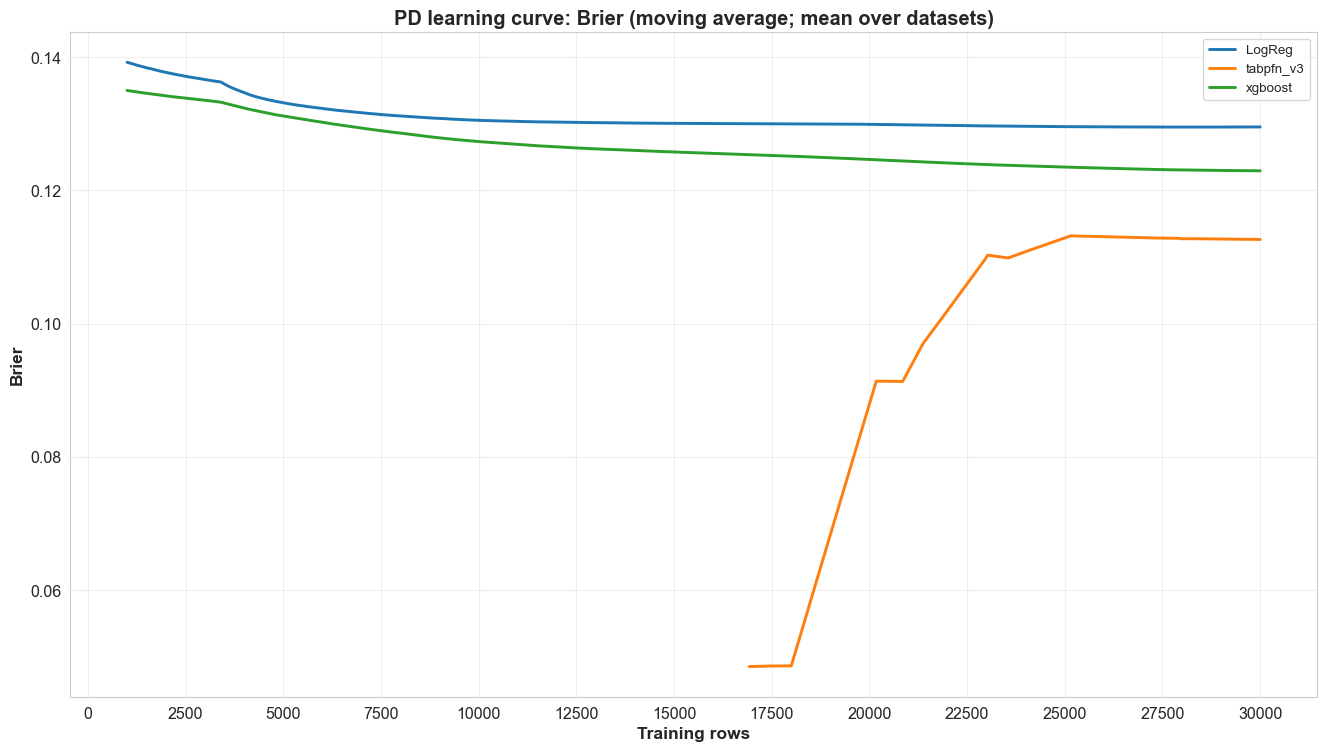

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_brier_smooth.pdf')

In [4]:
learning_curve(pd_df, 'Brier', task_name='PD', out_dir=FIGURES_DIR / 'pd')
learning_curve(pd_df, 'Brier', task_name='PD', smooth=True, out_dir=FIGURES_DIR / 'pd')

## LGD — R²

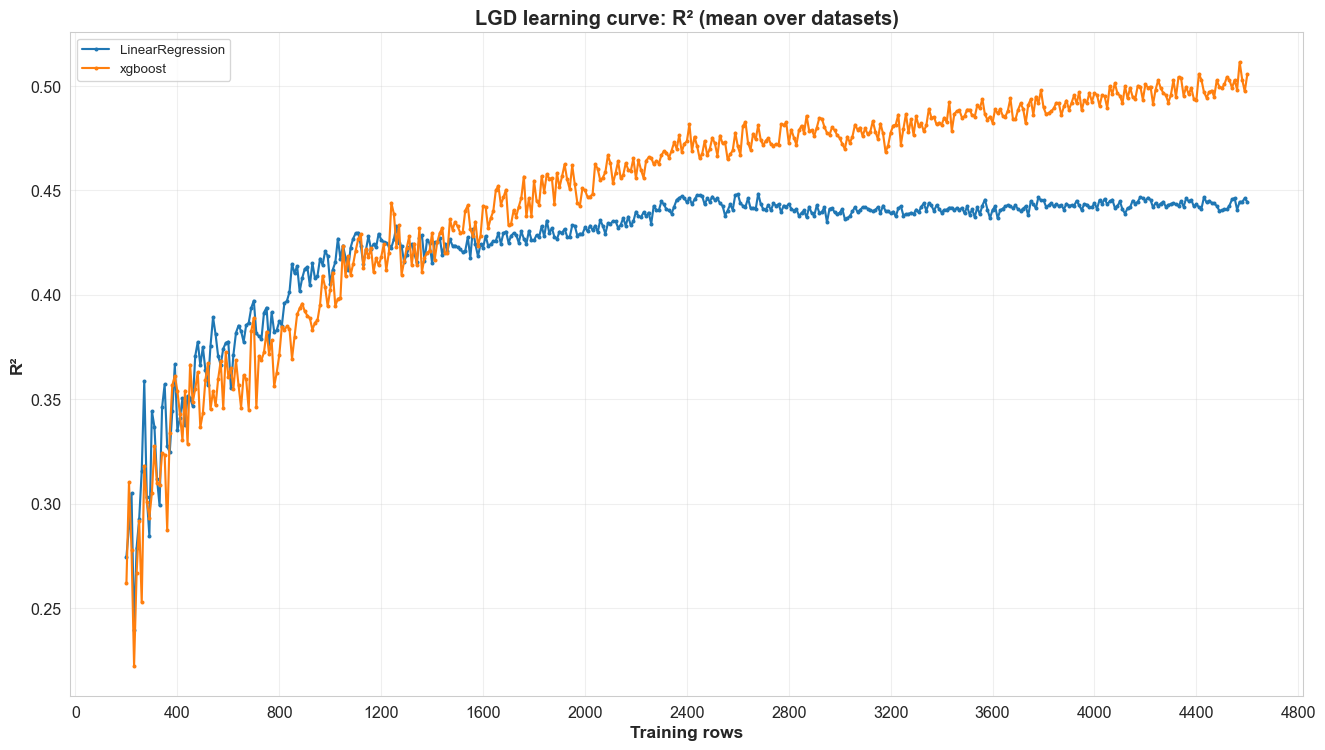

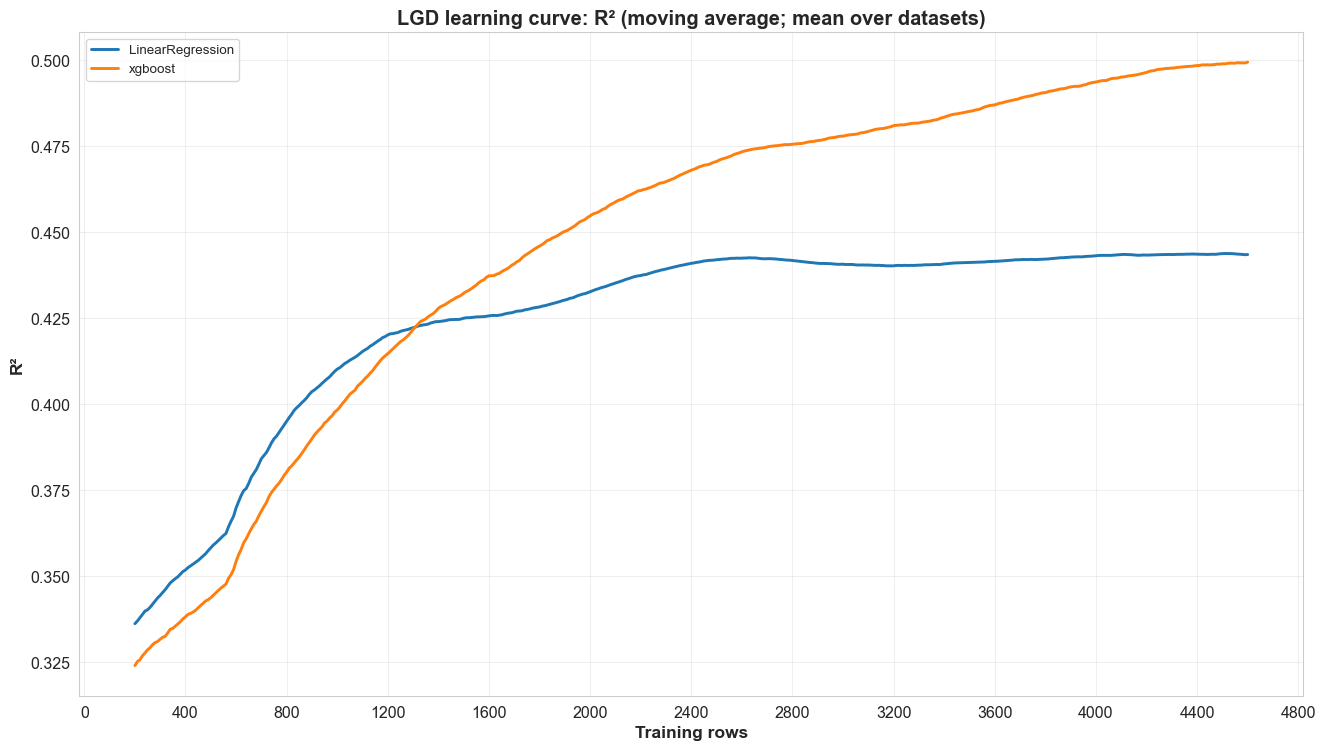

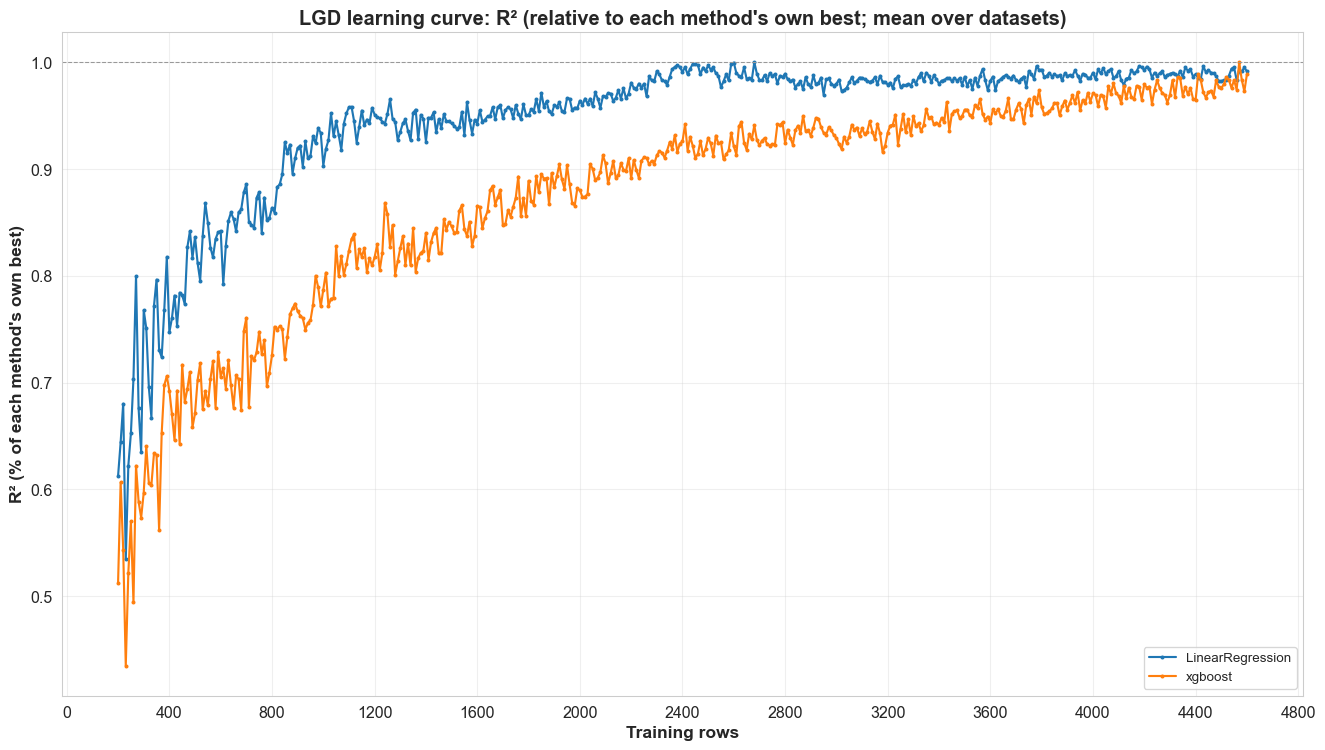

In [5]:
if lgd_df is not None:
    learning_curve(lgd_df, 'R2', task_name='LGD', out_dir=FIGURES_DIR / 'lgd')
    learning_curve(lgd_df, 'R2', task_name='LGD', smooth=True,   out_dir=FIGURES_DIR / 'lgd')
    learning_curve(lgd_df, 'R2', task_name='LGD', relative=True, out_dir=FIGURES_DIR / 'lgd')

## Data efficiency — training rows to reach 95% of each method's own plateau

In [6]:
import pandas as _pd
g = pd_df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.AUC'].max() * 0.95
    hit = gg[gg['metric.AUC'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='rows to reach 95% of own max AUC').sort_values())

LogReg        1600
xgboost       6550
tabpfn_v3    16925
Name: rows to reach 95% of own max AUC, dtype: int64

## Summary (at the largest training-set size)

In [7]:
full = pd_df[pd_df['sweep_value'] == pd_df['sweep_value'].max()]
pd_summary_text(full, task_name='Experiment 2 — PD @ max train rows')

Experiment 2 — PD @ max train rows — mean of every metric per method   (datasets: 9, methods: 3)
              AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Precision  Recall  Optimal_Threshold      AP  AP_baseline  AP_minus_baseline  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure  time_s (median)
method                                                                                                                                                                                                                                                                                              
tabpfn_v3  0.8134  0.6269  0.4926         0.4485  0.5519    0.7885             0.7218  0.4291  0.1128  0.0175   0.3606     0.5166  0.6273             0.2628  0.5532       0.1975             0.3557                    0.6460                    0.1736      -2280.1400     0.3581           9.4880
xgboost    0.7321  0.464

'Experiment 2 — PD @ max train rows — mean of every metric per method   (datasets: 9, methods: 3)\n================================================================================================\n              AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Precision  Recall  Optimal_Threshold      AP  AP_baseline  AP_minus_baseline  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure  time_s (median)\nmethod                                                                                                                                                                                                                                                                                              \ntabpfn_v3  0.8134  0.6269  0.4926         0.4485  0.5519    0.7885             0.7218  0.4291  0.1128  0.0175   0.3606     0.5166  0.6273             0.2628  0.5532       0.1975             0.3557                   